In [15]:
# ACC102 Track 2 - 财务数据分析项目
# 作者：[Yanni.Qian24]
# 日期：2026年4月16日

In [16]:
import wrds
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [17]:
# 定义要分析的股票
# 建立 WRDS 连接（会使用 .pgpass 文件中的账号）
db = wrds.Connection()
print("WRDS 连接成功")

WRDS recommends setting up a .pgpass file.
Created .pgpass file successfully.
You can create this file yourself at any time with the create_pgpass_file() function.
Loading library list...
Done
WRDS 连接成功


In [18]:
query = """
SELECT a.gvkey, a.datadate, a.fyear, 
       a.act, a.lt, a.seq, a.sale, a.ni, a.oibdp,
       b.tic as ticker
FROM comp.funda a
JOIN comp.security b ON a.gvkey = b.gvkey
WHERE b.tic IN ('AAPL', 'MSFT')
  AND a.fyear BETWEEN 2019 AND 2024
  AND a.indfmt = 'INDL'
  AND a.datafmt = 'STD'
ORDER BY b.tic, a.datadate
"""
df = db.raw_sql(query, date_cols=['datadate'])
df.head()

,gvkey,datadate,fyear,act,lt,seq,sale,ni,oibdp,ticker
0,001690,2019-09-30,2019,162819.0,248028.0,90488.0,260174.0,55256.0,75230.0,AAPL
1,001690,2020-09-30,2020,143713.0,258549.0,65339.0,274515.0,57411.0,75988.0,AAPL
2,001690,2021-09-30,2021,134836.0,287912.0,63090.0,365817.0,94680.0,118449.0,AAPL
3,001690,2022-09-30,2022,135405.0,302083.0,50672.0,394328.0,99803.0,128137.0,AAPL
4,001690,2023-09-30,2023,143566.0,290437.0,62146.0,383285.0,96995.0,122801.0,AAPL


In [19]:
# 计算总资产（总负债 + 股东权益）
df['total_assets'] = df['lt'] + df['seq']

# 计算比率
df['roe'] = df['ni'] / df['seq']
df['roa'] = df['ni'] / df['total_assets']
df['debt_to_equity'] = df['lt'] / df['seq']
df['operating_margin'] = df['oibdp'] / df['sale']

# 查看列名（确认有哪些列）
print(df.columns)

# 查看结果（先不看公司标识，因为还没加 ticker 列）
df[['fyear', 'roe', 'roa', 'debt_to_equity']].head()

Index(['gvkey', 'datadate', 'fyear', 'act', 'lt', 'seq', 'sale', 'ni', 'oibdp',
       'ticker', 'total_assets', 'roe', 'roa', 'debt_to_equity',
       'operating_margin'],
      dtype='object')


,fyear,roe,roa,debt_to_equity
0,2019,0.610645,0.16323,2.741004
1,2020,0.878664,0.177256,3.957039
2,2021,1.500713,0.269742,4.563512
3,2022,1.969589,0.282924,5.961537
4,2023,1.56076,0.275098,4.673462


In [20]:
# 按公司分组查看最新一年数据
latest = df.groupby('ticker').last()[['fyear', 'roe', 'roa', 'debt_to_equity']]
latest

,fyear,roe,roa,debt_to_equity
ticker,,,,
AAPL,2024,1.645935,0.256825,5.40878
MSFT,2024,0.328281,0.172086,0.907661


/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20928 (\N{CJK UNIFIED IDEOGRAPH-51C0}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 36164 (\N{CJK UNIFIED IDEOGRAPH-8D44}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20135 (\N{CJK UNIFIED IDEOGRAPH-4EA7}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 25910 (\N{CJK UNIFIED IDEOGRAPH-6536}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 30410 (\N{CJK UNIFIED IDEOGRAPH-76CA}) missing from font(s) DejaV

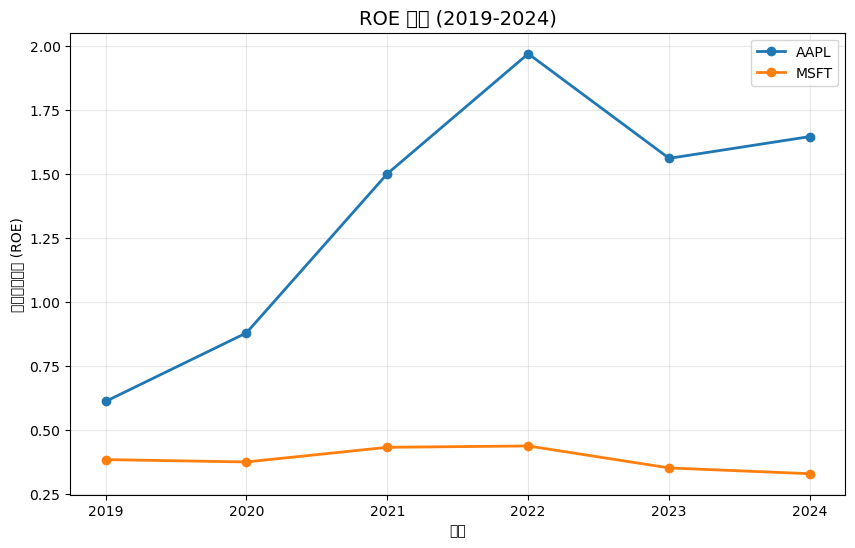

In [21]:
plt.figure(figsize=(10,6))
for ticker in ['AAPL', 'MSFT']:
    subset = df[df['ticker'] == ticker]
    plt.plot(subset['fyear'], subset['roe'], marker='o', linewidth=2, label=ticker)
plt.title('ROE 对比 (2019-2024)', fontsize=14)
plt.xlabel('年份')
plt.ylabel('净资产收益率 (ROE)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 36127 (\N{CJK UNIFIED IDEOGRAPH-8D1F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20538 (\N{CJK UNIFIED IDEOGRAPH-503A}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 26435 (\N{CJK UNIFIED IDEOGRAPH-6743}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 30410 (\N{CJK UNIFIED IDEOGRAPH-76CA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 27604 (\N{CJK UNIFIED IDEOGRAPH-6BD4}) missing from font(s) DejaV

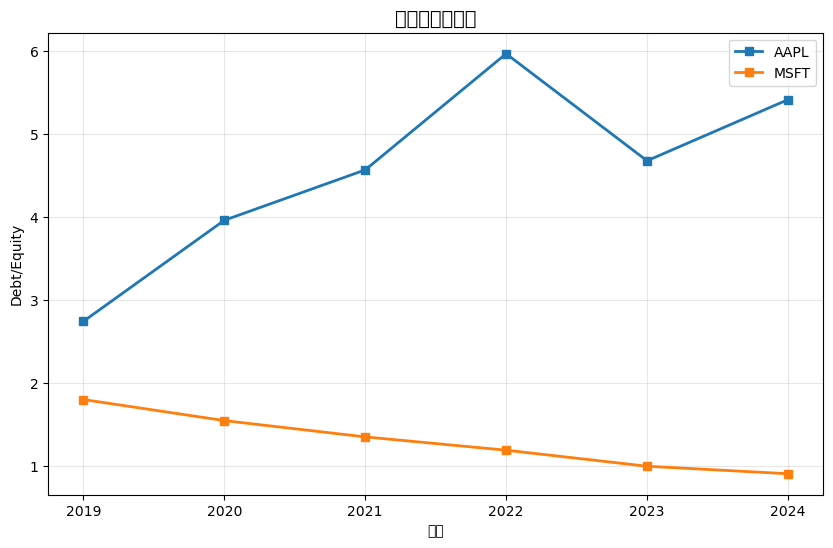

In [22]:
plt.figure(figsize=(10,6))
for ticker in ['AAPL', 'MSFT']:
    subset = df[df['ticker'] == ticker]
    plt.plot(subset['fyear'], subset['debt_to_equity'], marker='s', linewidth=2, label=ticker)
plt.title('负债权益比对比', fontsize=14)
plt.xlabel('年份')
plt.ylabel('Debt/Equity')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [23]:
summary = df.groupby('ticker').agg({
    'roe': ['mean', 'std'],
    'roa': ['mean', 'std'],
    'debt_to_equity': ['mean', 'std']
}).round(4)
summary

roe             roa         debt_to_equity        
          mean     std    mean     std           mean     std
ticker                                                       
AAPL    1.3611  0.5112  0.2375   0.053         4.5509  1.1287
MSFT    0.3842  0.0432  0.1691  0.0232          1.299   0.338

In [24]:
# ========== 分析结论 ==========
# 1. AAPL 的平均 ROE 高于 MSFT，但波动性也更大（标准差更高）
# 2. AAPL 的负债权益比显著高于 MSFT，说明其 ROE 优势部分来自更高的财务杠杆
# 3. 两家公司的 ROA 水平相近，核心盈利能力相当
# 4. 投资建议：追求高回报可考虑 AAPL，追求稳健可考虑 MSFT
# 5. 数据来源：WRDS Compustat，访问日期：2026年4月16日
print("分析结论如上。")

分析结论如上。


In [25]:
db.close()
print("WRDS 连接已关闭")

WRDS 连接已关闭
